In [ ]:
import argparse
import pickle
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os
# Define the base directory for fraud detection data in Google Drive
data_dir = Path("/content/drive/MyDrive/FraudDetection/New_version/")

# Ensure the directory exists
data_dir.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {data_dir}")

# Define the path to the fraudTrain.csv and fraudTest.csv files within that directory.
input_file_name_train = "fraudTrain.csv"
input_file_path_train = data_dir / input_file_name_train

input_file_name_test = "fraudTest.csv"
input_file_path_test = data_dir / input_file_name_test

# Check if train file exists
if not input_file_path_train.exists():
    print(f"Warning: The file '{input_file_name_train}' was not found at '{input_file_path_train}'. "
          "Please ensure it is present for the preprocessing step.")
else:
    print(f"Input file '{input_file_name_train}' found at: {input_file_path_train}")

# Check if test file exists
if not input_file_path_test.exists():
    print(f"Warning: The file '{input_file_name_test}' was not found at '{input_file_path_test}'. "
          "Please ensure it is present for the preprocessing step.")
else:
    print(f"Input file '{input_file_name_test}' found at: {input_file_path_test}")

# The original cell's `os.listdir` and `shutil.copy` logic is removed as it was
# causing the error and is redundant if the input file path is directly specified
# and the file is expected to be in the Google Drive directory.

Data directory: /content/drive/MyDrive/FraudDetection/New_version
Input file 'fraudTrain.csv' found at: /content/drive/MyDrive/FraudDetection/New_version/fraudTrain.csv
Input file 'fraudTest.csv' found at: /content/drive/MyDrive/FraudDetection/New_version/fraudTest.csv


In [ ]:
def load_data(path: str) -> pd.DataFrame:
    """Load CSV, dropping the unnamed index column if present."""
    df = pd.read_csv(path, index_col=0)
    print(f"[load] {len(df):,} rows × {df.shape[1]} columns")
    return df

In [ ]:
df=load_data( )

TypeError: load_data() missing 1 required positional argument: 'path'

In [ ]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df = df.drop(columns=['cc_num', 'first', 'last','trans_num'])
display(df.head())

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 18 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   merchant               1296675 non-null  object 
 2   category               1296675 non-null  object 
 3   amt                    1296675 non-null  float64
 4   gender                 1296675 non-null  object 
 5   street                 1296675 non-null  object 
 6   city                   1296675 non-null  object 
 7   state                  1296675 non-null  object 
 8   zip                    1296675 non-null  int64  
 9   lat                    1296675 non-null  float64
 10  long                   1296675 non-null  float64
 11  city_pop               1296675 non-null  int64  
 12  job                    1296675 non-null  object 
 13  dob                    1296675 non-null  object 
 14  unix_time              

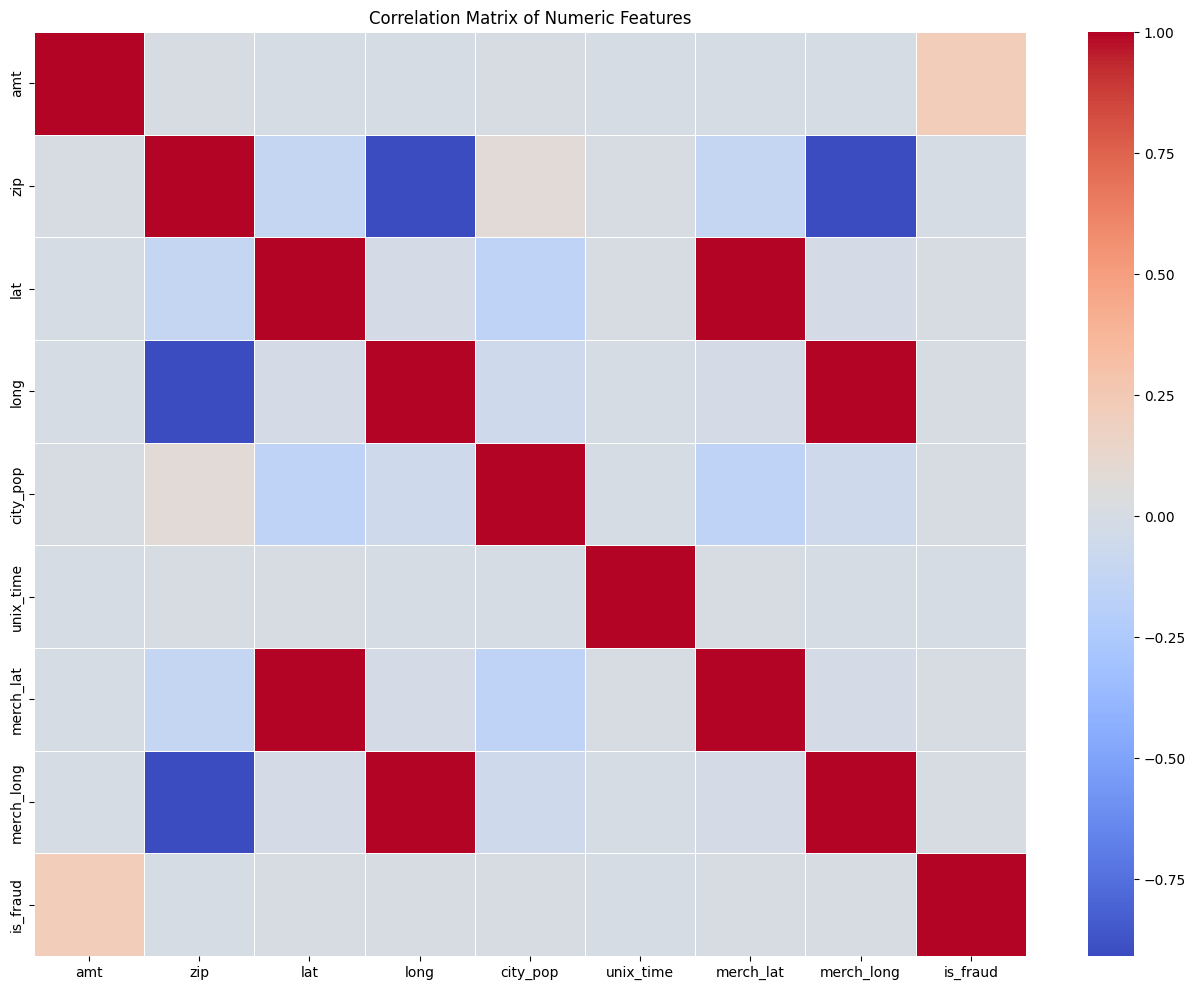

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Finding Outliers using the IQR Method

In [ ]:
# Select only numeric columns for outlier detection
numeric_cols_for_outliers = df.select_dtypes(include=np.number).columns.tolist()

print("Outlier Detection using IQR Method:")
for col in numeric_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(outliers)

    if outliers_count > 0:
        print(f"- Column '{col}': {outliers_count} outliers found ({outliers_count / len(df) * 100:.2f}% of total data)")
    else:
        print(f"- Column '{col}': No outliers found (or 0% of total data)")

Outlier Detection using IQR Method:
- Column 'amt': 67290 outliers found (5.19% of total data)
- Column 'zip': No outliers found (or 0% of total data)
- Column 'lat': 4679 outliers found (0.36% of total data)
- Column 'long': 49922 outliers found (3.85% of total data)
- Column 'city_pop': 242674 outliers found (18.72% of total data)
- Column 'unix_time': No outliers found (or 0% of total data)
- Column 'merch_lat': 4967 outliers found (0.38% of total data)
- Column 'merch_long': 41994 outliers found (3.24% of total data)
- Column 'is_fraud': 7506 outliers found (0.58% of total data)


### Visualizing Numeric Feature Distributions by Fraud Status

/tmp/ipykernel_1948/2800945384.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y=col, data=df, palette='viridis')
/tmp/ipykernel_1948/2800945384.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y=col, data=df, palette='viridis')
/tmp/ipykernel_1948/2800945384.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y=col, data=df, palette='viridis')
/tmp/ipykernel_1948/2800945384.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

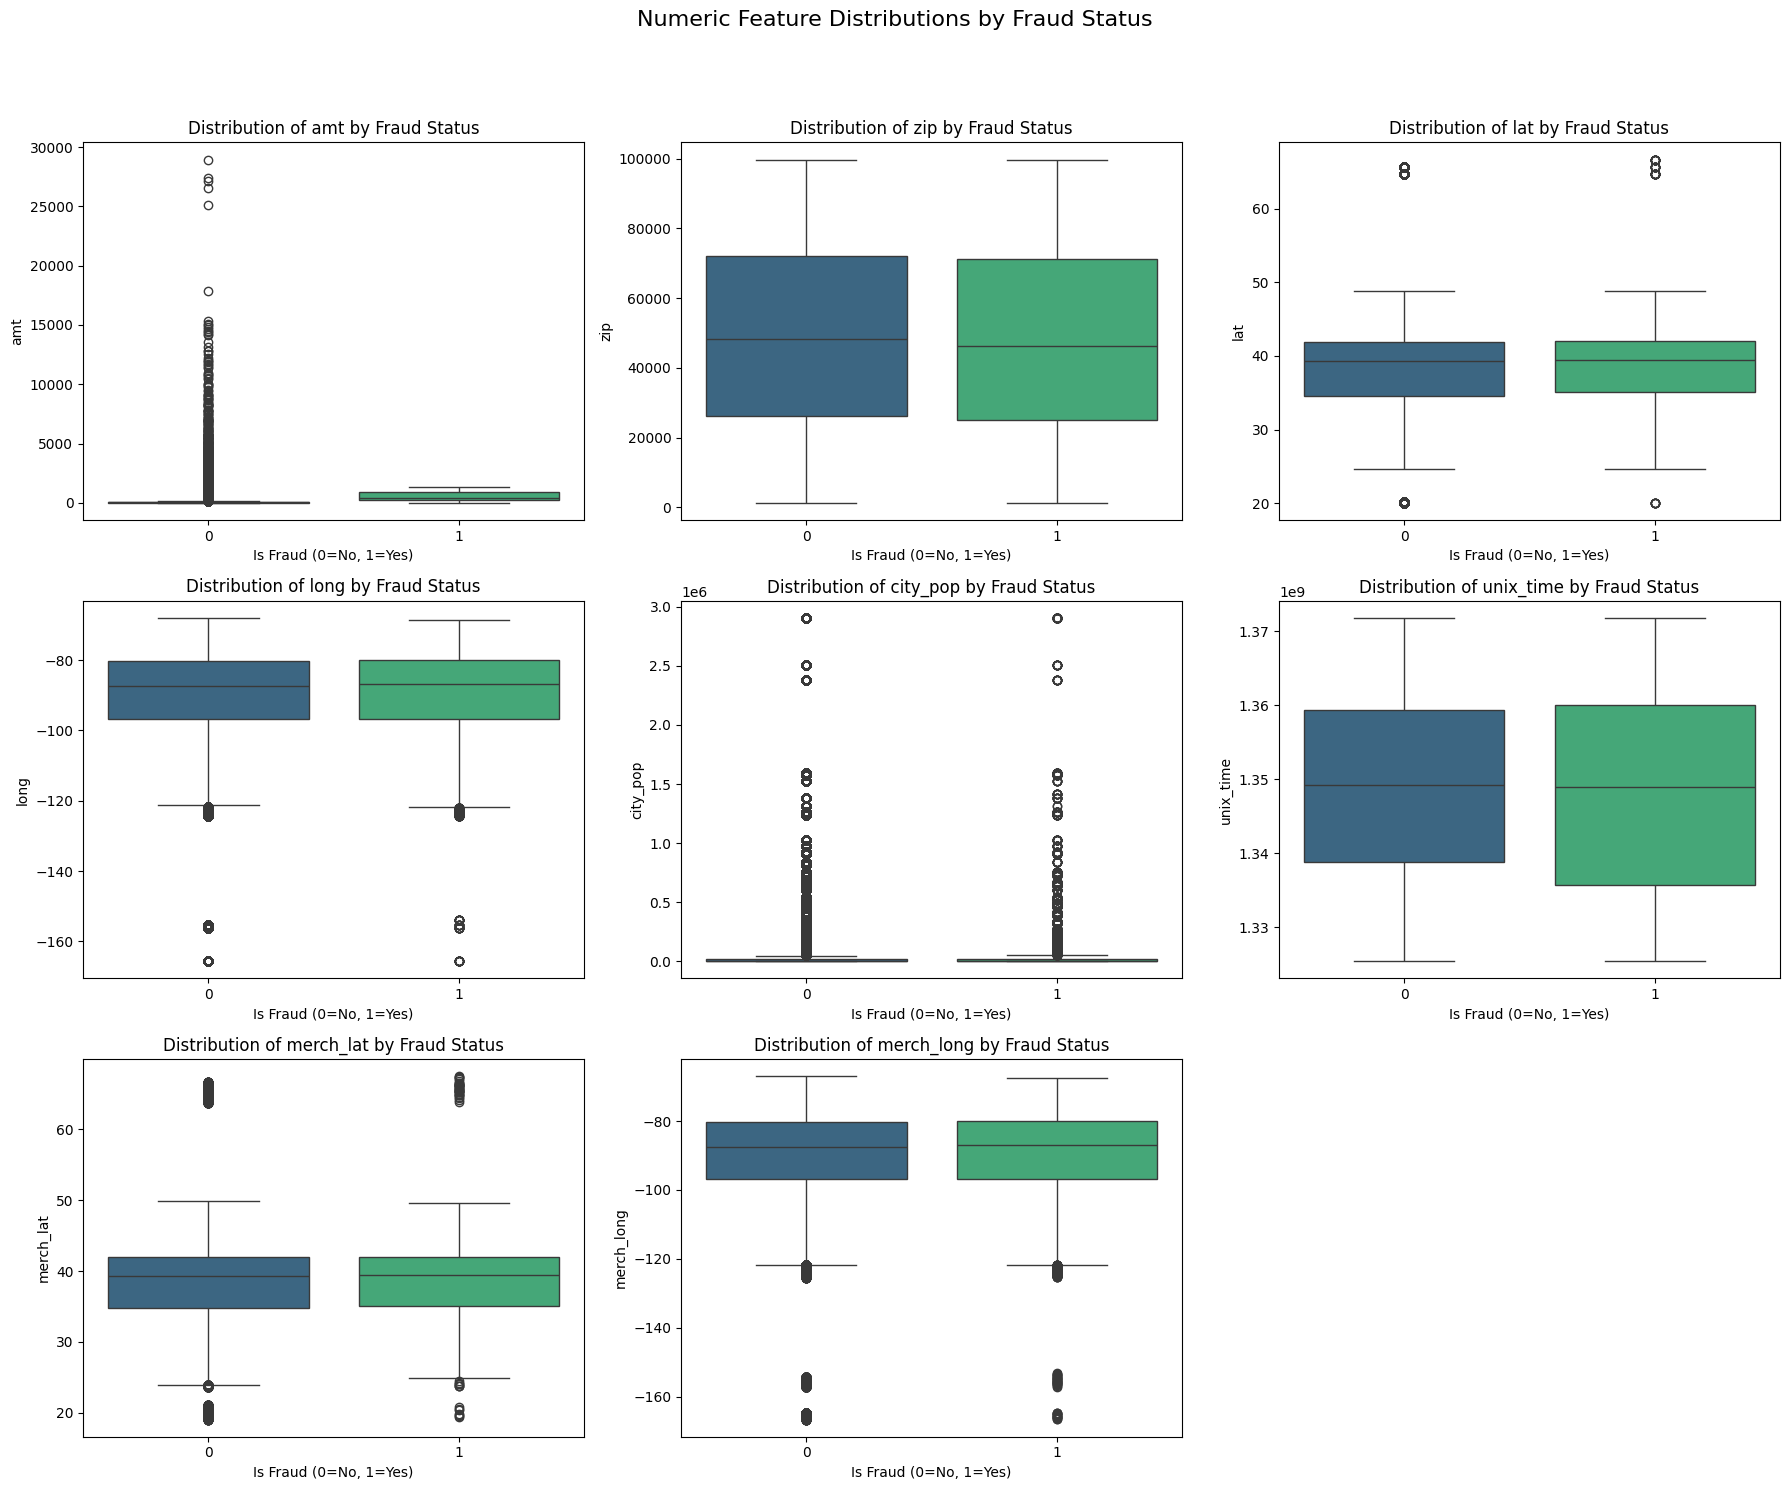

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-select numeric columns from the current DataFrame 'df'
numeric_cols_for_distribution = df.select_dtypes(include=np.number).columns.tolist()

# Remove 'is_fraud' from the list of columns to plot against itself if it's there
if 'is_fraud' in numeric_cols_for_distribution:
    numeric_cols_for_distribution.remove('is_fraud')

cols_per_row = 3
num_plots = len(numeric_cols_for_distribution)
num_rows = (num_plots + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(cols_per_row * 6, num_rows * 5))
plt.suptitle('Numeric Feature Distributions by Fraud Status', y=1.02, fontsize=16)

for i, col in enumerate(numeric_cols_for_distribution):
    plt.subplot(num_rows, cols_per_row, i + 1)
    sns.boxplot(x='is_fraud', y=col, data=df, palette='viridis')
    plt.title(f'Distribution of {col} by Fraud Status')
    plt.xlabel('Is Fraud (0=No, 1=Yes)')
    plt.ylabel(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

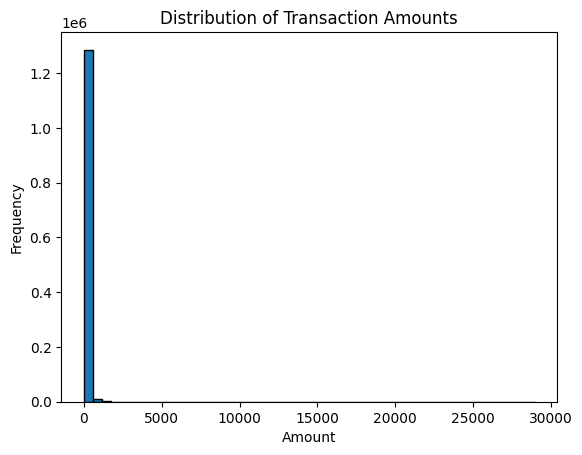

In [ ]:
plt.hist(df['amt'], bins=50, edgecolor='k')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts')
plt.show()

### Log Transformation of `amt` and its Distribution

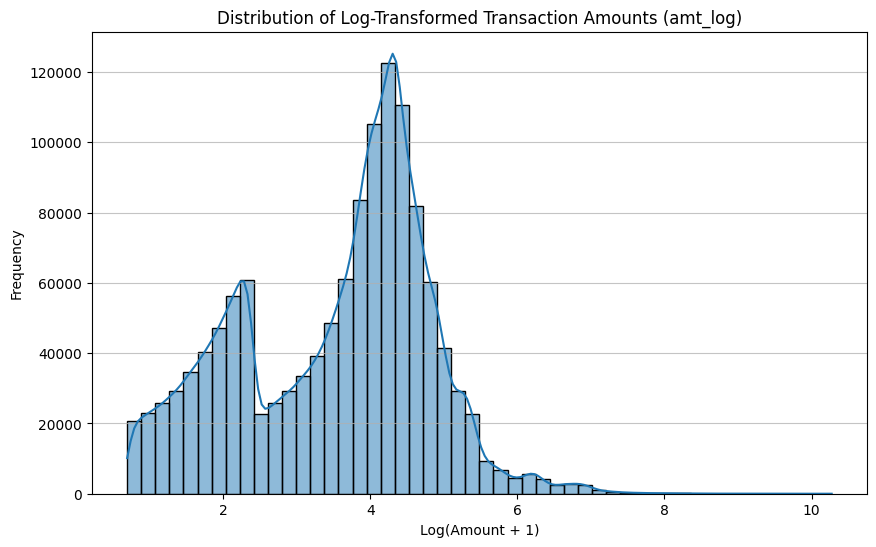

In [ ]:
# Apply log transformation to the 'amt' column
df['amt_log'] = np.log1p(df['amt'])

# Plot the histogram of the transformed 'amt_log' column
plt.figure(figsize=(10, 6))
sns.histplot(df['amt_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Transaction Amounts (amt_log)')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Distribution of Log-Transformed Amount by Fraud Status

/tmp/ipykernel_1948/3732031153.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt_log', data=df, palette='coolwarm')


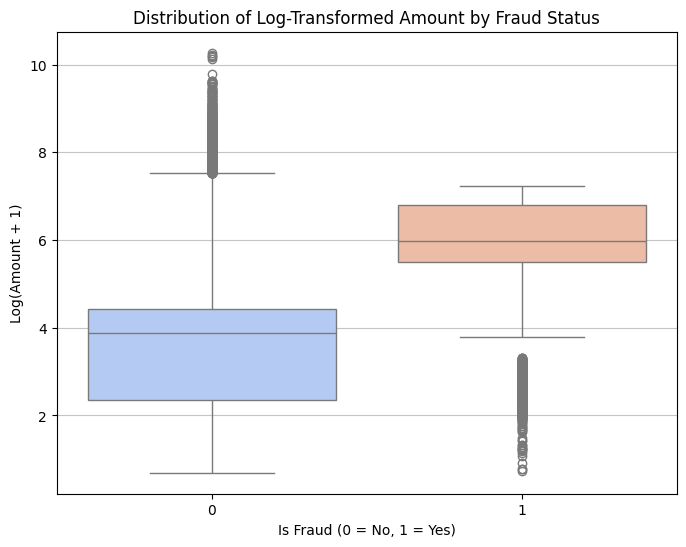

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_fraud', y='amt_log', data=df, palette='coolwarm')
plt.title('Distribution of Log-Transformed Amount by Fraud Status')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Log(Amount + 1)')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Histograms of Log-Transformed Amount by Fraud Status

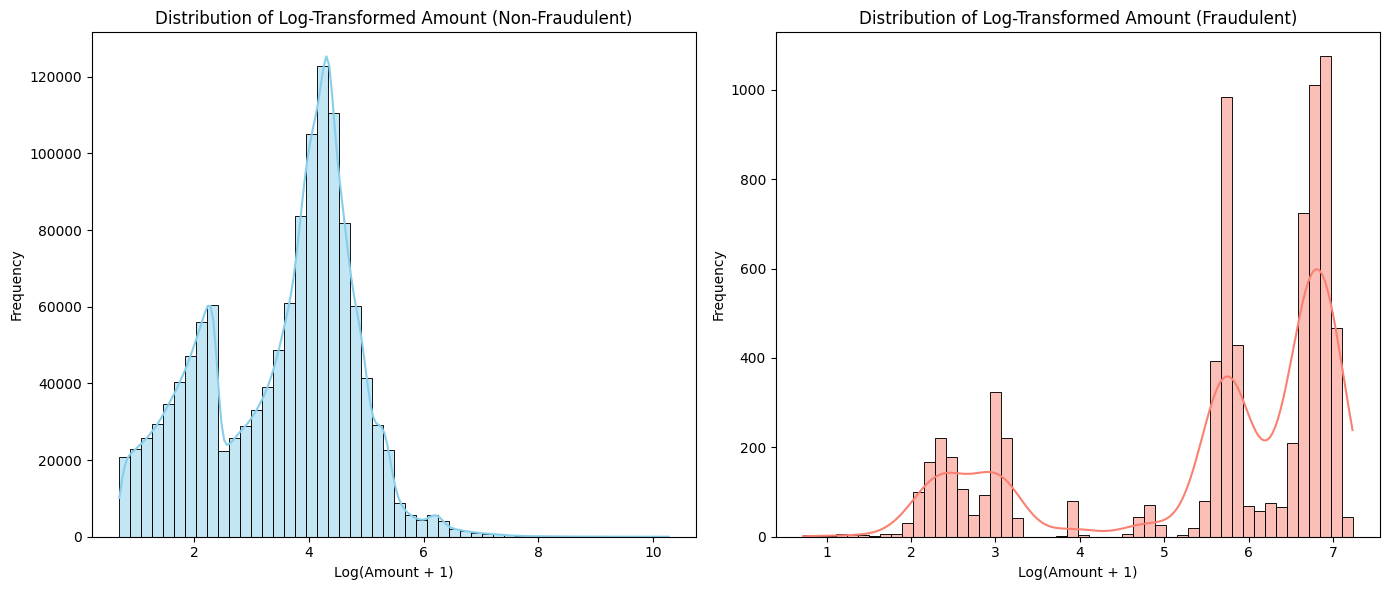

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df[df['is_fraud'] == 0]['amt_log'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Log-Transformed Amount (Non-Fraudulent)')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df[df['is_fraud'] == 1]['amt_log'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Log-Transformed Amount (Fraudulent)')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Convert 'trans_date_trans_time' to datetime objects
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract hour, day, and month
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_month'] = df['trans_date_trans_time'].dt.month

print("Extracted 'trans_hour', 'trans_day', and 'trans_month' from 'trans_date_trans_time'.")
print("First 5 rows with new columns:")
display(df[['trans_date_trans_time', 'trans_hour', 'trans_day', 'trans_month']].head())

Extracted 'trans_hour', 'trans_day', and 'trans_month' from 'trans_date_trans_time'.
First 5 rows with new columns:


,trans_date_trans_time,trans_hour,trans_day,trans_month
0,2019-01-01 00:00:18,0,1,1
1,2019-01-01 00:00:44,0,1,1
2,2019-01-01 00:00:51,0,1,1
3,2019-01-01 00:01:16,0,1,1
4,2019-01-01 00:03:06,0,1,1


### Distribution of Time-Based Features by Fraud Status

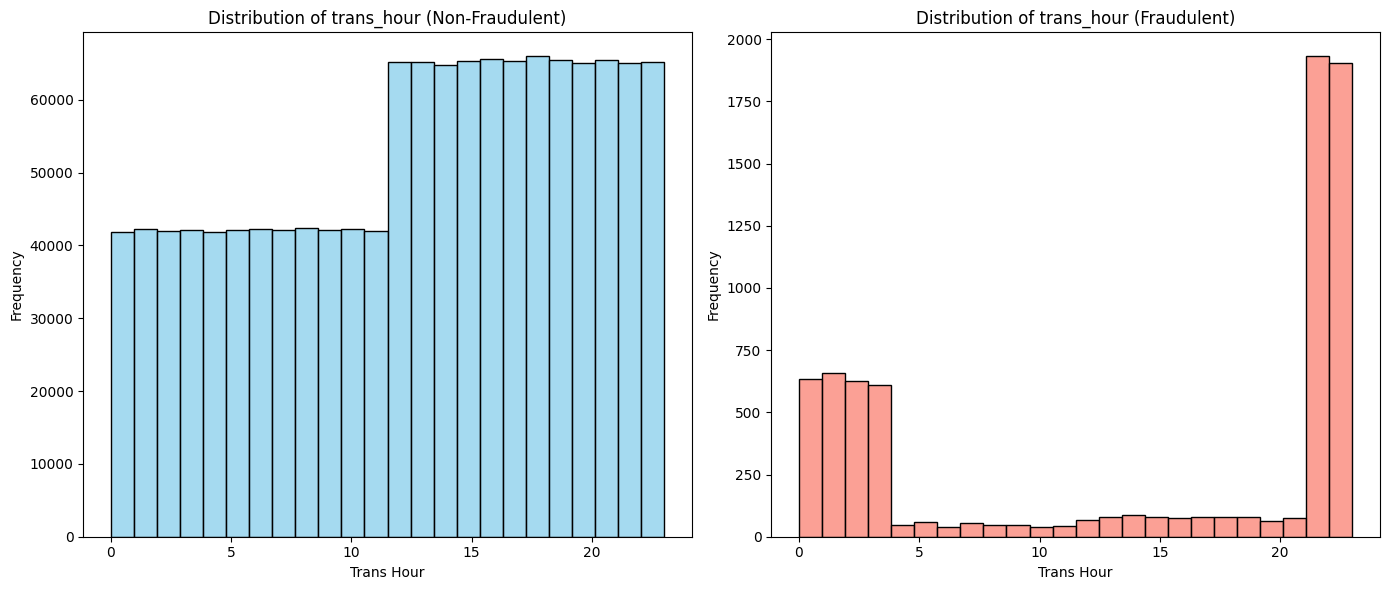

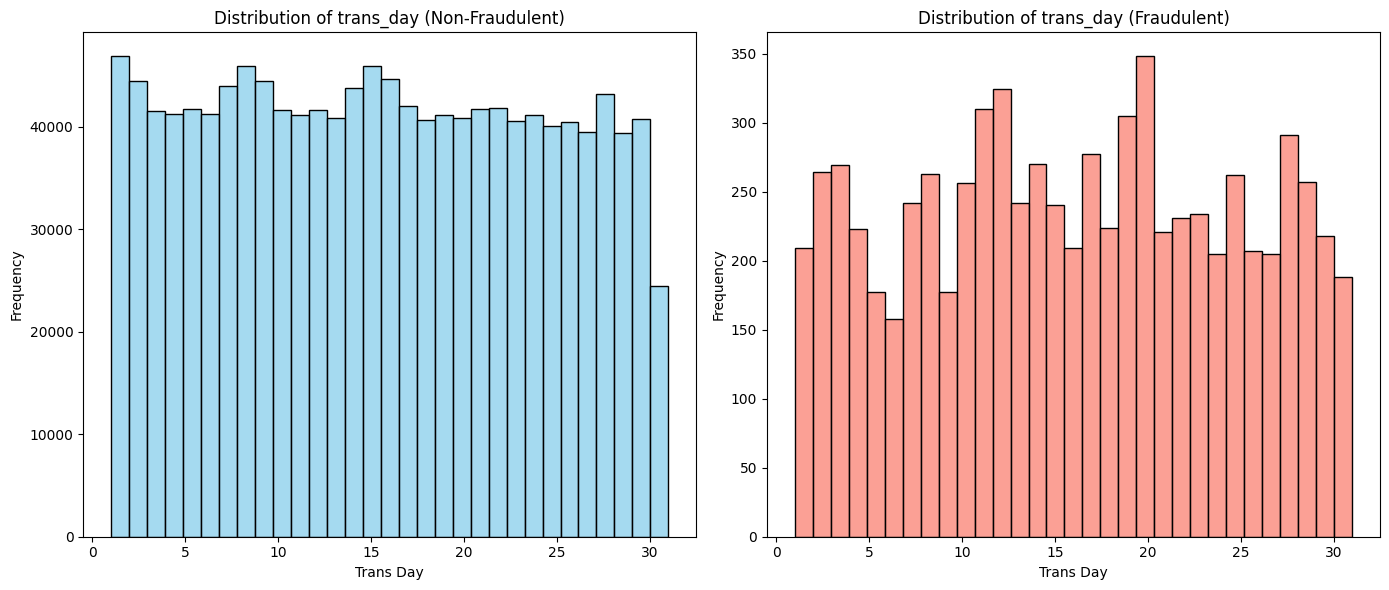

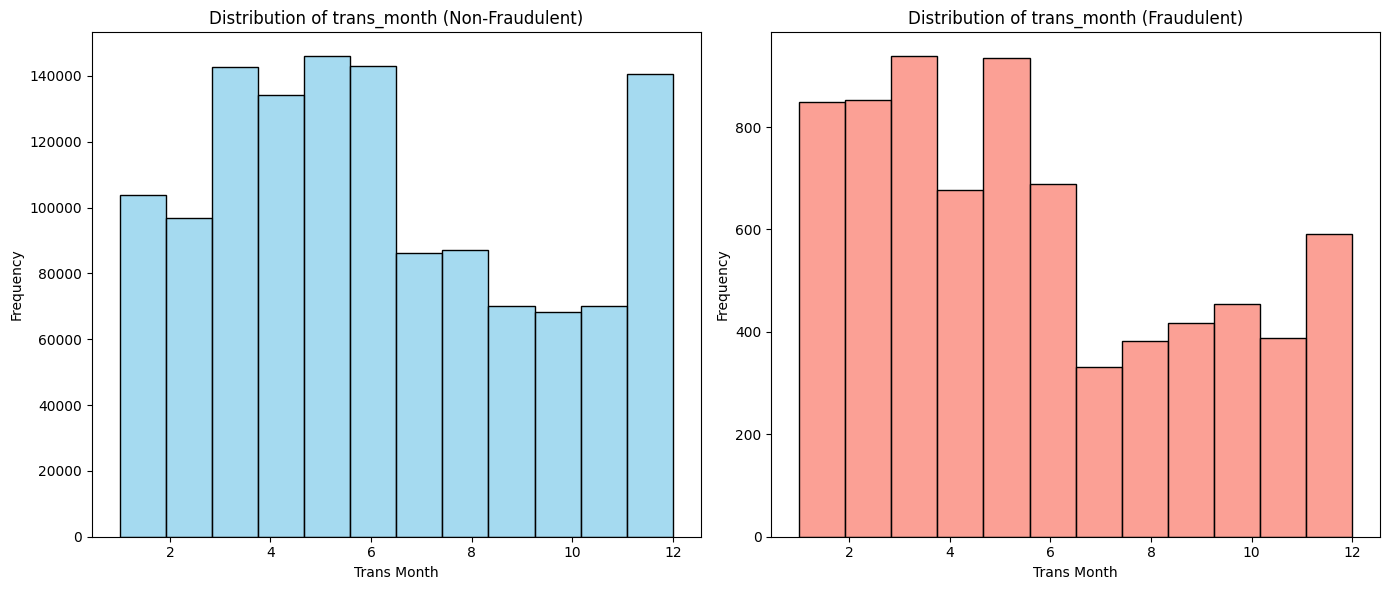

In [ ]:
time_features = ['trans_hour', 'trans_day', 'trans_month']

for feature in time_features:
    plt.figure(figsize=(14, 6))

    # Histogram for Non-Fraudulent Transactions
    plt.subplot(1, 2, 1)
    sns.histplot(df[df['is_fraud'] == 0][feature], bins=len(df[feature].unique()), kde=False, color='skyblue')
    plt.title(f'Distribution of {feature} (Non-Fraudulent)')
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel('Frequency')

    # Histogram for Fraudulent Transactions
    plt.subplot(1, 2, 2)
    sns.histplot(df[df['is_fraud'] == 1][feature], bins=len(df[feature].unique()), kde=False, color='salmon')
    plt.title(f'Distribution of {feature} (Fraudulent)')
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

### Cities and their Populations

In [ ]:
# Select unique city and city_pop combinations
cities_population = df[['city', 'city_pop']].drop_duplicates().sort_values(by='city').reset_index(drop=True)
display(cities_population)

,city,city_pop
0,Achille,608
1,Acworth,477
2,Adams,3508
3,Afton,937
4,Afton,2916
...,...,...
923,Woods Cross,13983
924,Woodville,3395
925,Yellowstone National Park,369
926,Zaleski,341


### Cities with the Most Fraud and Their Populations

In [ ]:
fraud_by_city = df.groupby(['city', 'city_pop'])['is_fraud'].sum().reset_index()
fraud_by_city = fraud_by_city.sort_values(by='is_fraud', ascending=False)
display(fraud_by_city.head(50))

,city,city_pop,is_fraud
378,Houston,2906700,39
578,Naples,276002,29
388,Huntsville,190178,29
841,Tulsa,413574,27
837,Topeka,163415,27
209,Dallas,1263321,27
228,Detroit,673342,26
753,San Antonio,1595797,25
167,Clearwater,172247,24
66,Beaver Falls,28425,24


### Horizontal Bar Graph: Top 10 Cities by Fraud Count

/tmp/ipykernel_1948/1994409217.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_fraud', y='city', data=top_10_fraud_cities, palette='viridis')


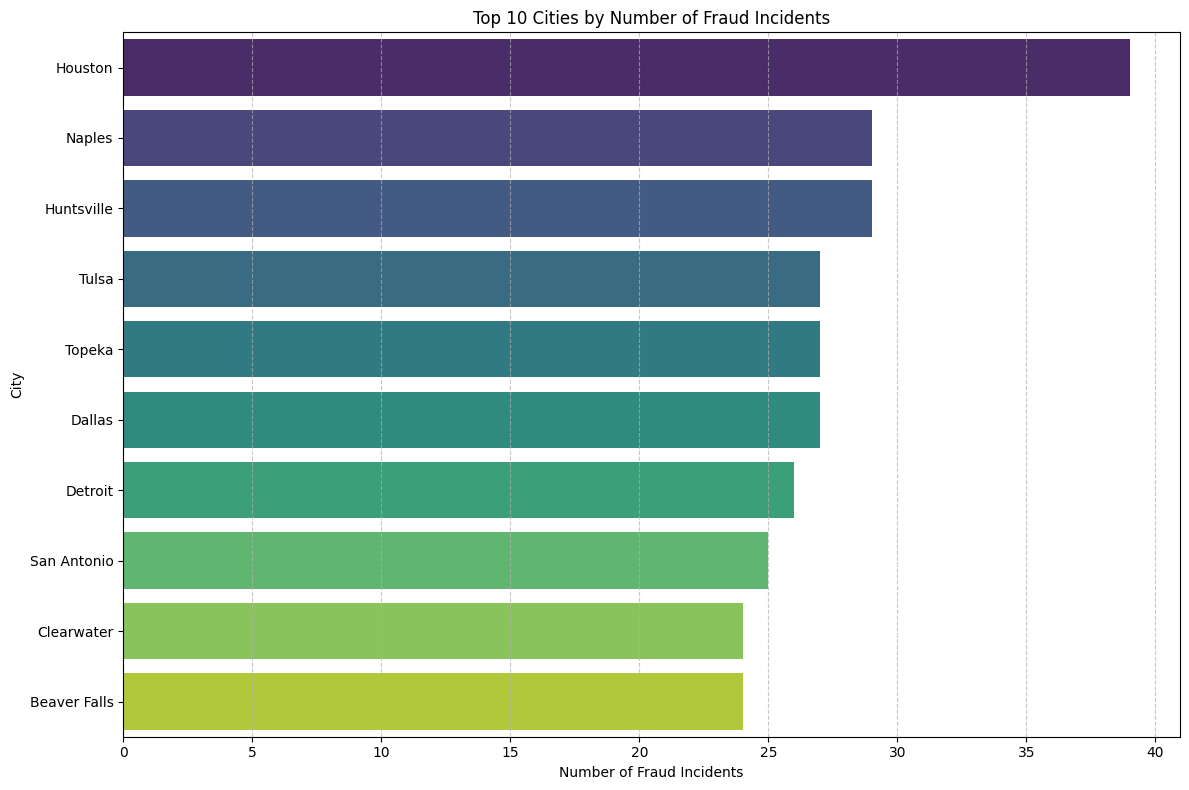

In [ ]:
# Select the top 10 cities with the most fraud for better visualization
top_10_fraud_cities = fraud_by_city.head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x='is_fraud', y='city', data=top_10_fraud_cities, palette='viridis')
plt.title('Top 10 Cities by Number of Fraud Incidents')
plt.xlabel('Number of Fraud Incidents')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Merchants with the Most Fraud

In [ ]:
fraud_by_merchant = df.groupby('merchant')['is_fraud'].sum().reset_index()
fraud_by_merchant = fraud_by_merchant.sort_values(by='is_fraud', ascending=False)
display(fraud_by_merchant.head(100))

,merchant,is_fraud
494,fraud_Rau and Sons,49
337,fraud_Kozey-Boehm,48
105,fraud_Cormier LLC,48
645,fraud_Vandervort-Funk,47
146,fraud_Doyle Ltd,47
...,...,...
504,"fraud_Reichert, Shanahan and Hayes",27
359,fraud_Kutch and Sons,26
601,fraud_Stoltenberg-Beatty,26
256,fraud_Hills-Witting,26


### Categories with the Most Fraud

In [ ]:
fraud_by_category = df.groupby('category')['is_fraud'].sum().reset_index()
fraud_by_category = fraud_by_category.sort_values(by='is_fraud', ascending=False)
display(fraud_by_category.head(10))

,category,is_fraud
4,grocery_pos,1743
11,shopping_net,1713
8,misc_net,915
12,shopping_pos,843
2,gas_transport,618
9,misc_pos,250
7,kids_pets,239
0,entertainment,233
10,personal_care,220
6,home,198


### Jobs with the Most Fraud

In [ ]:
fraud_by_job = df.groupby('job')['is_fraud'].sum().reset_index()
fraud_by_job = fraud_by_job.sort_values(by='is_fraud', ascending=False)
display(fraud_by_job.head(100))

,job,is_fraud
286,Materials engineer,62
477,Trading standards officer,56
308,Naval architect,53
187,Exhibition designer,51
439,"Surveyor, land/geomatics",50
...,...,...
320,Operations geologist,23
87,Clinical biochemist,23
212,"Geologist, engineering",23
194,Financial adviser,23


### Saving Processed Training and Test Data

In [ ]:
def process_and_select_columns(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Applies necessary transformations and selects required columns."""
    # Ensure 'trans_date_trans_time' is datetime for 'trans_hour' extraction
    if 'trans_date_trans_time' in df_raw.columns and not pd.api.types.is_datetime64_any_dtype(df_raw['trans_date_trans_time']):
        df_raw['trans_date_trans_time'] = pd.to_datetime(df_raw['trans_date_trans_time'])

    # Extract 'trans_hour' if not already present
    if 'trans_hour' not in df_raw.columns:
        df_raw['trans_hour'] = df_raw['trans_date_trans_time'].dt.hour

    # Create 'amt_log' if not already present
    if 'amt_log' not in df_raw.columns and 'amt' in df_raw.columns:
        df_raw['amt_log'] = np.log1p(df_raw['amt'])
    elif 'amt_log' not in df_raw.columns and 'amt' not in df_raw.columns:
        print("Warning: 'amt' column not found to create 'amt_log'. Skipping 'amt_log'.")

    # Select the desired columns, ensuring they exist
    selected_cols = []
    if 'trans_hour' in df_raw.columns:
        selected_cols.append('trans_hour')
    if 'category' in df_raw.columns:
        selected_cols.append('category')
    if 'amt_log' in df_raw.columns:
        selected_cols.append('amt_log')
    if 'is_fraud' in df_raw.columns: # Added 'is_fraud' as requested
        selected_cols.append('is_fraud')

    if not selected_cols:
        raise ValueError("No specified columns ('trans_hour', 'category', 'amt_log', 'is_fraud') found in the DataFrame.")

    return df_raw[selected_cols]

# --- Process and Save Training Data ---
print(f"Loading training data from: {input_file_path_train}")
train_df_raw = load_data(input_file_path_train)
processed_train_df = process_and_select_columns(train_df_raw)

output_train_file_name = data_dir / f"processed_{input_file_name_train}"
processed_train_df.to_csv(output_train_file_name, index=False)
print(f"Processed training data saved to: {output_train_file_name}")
display(processed_train_df.head())

# --- Process and Save Test Data ---
print(f"\nLoading test data from: {input_file_path_test}")
test_df_raw = load_data(input_file_path_test)
processed_test_df = process_and_select_columns(test_df_raw)

output_test_file_name = data_dir / f"processed_{input_file_name_test}"
processed_test_df.to_csv(output_test_file_name, index=False)
print(f"Processed test data saved to: {output_test_file_name}")
display(processed_test_df.head())

Loading training data from: /content/drive/MyDrive/FraudDetection/New_version/fraudTrain.csv
[load] 1,296,675 rows × 22 columns
Processed training data saved to: /content/drive/MyDrive/FraudDetection/New_version/processed_fraudTrain.csv


,trans_hour,category,amt_log,is_fraud
0,0,misc_net,1.786747,0
1,0,grocery_pos,4.684259,0
2,0,entertainment,5.398660,0
3,0,gas_transport,3.828641,0
4,0,misc_pos,3.760269,0



Loading test data from: /content/drive/MyDrive/FraudDetection/New_version/fraudTest.csv
[load] 555,719 rows × 22 columns
Processed test data saved to: /content/drive/MyDrive/FraudDetection/New_version/processed_fraudTest.csv


,trans_hour,category,amt_log,is_fraud
0,12,personal_care,1.350667,0
1,12,personal_care,3.428813,0
2,12,health_fitness,3.744314,0
3,12,misc_pos,4.111693,0
4,12,travel,1.432701,0


In [ ]:
df_fraud_only=load_data("/content/drive/MyDrive/FraudDetection/New_version/processed_fraudTest.csv" )

[load] 555,719 rows × 3 columns


### Extracting Fraudulent Cases from Test Data

In [ ]:
# Filter the processed test data for fraudulent transactions
# df_fraud_only is available from a previous cell's execution and contains the processed test data.
fraud_test_df = df_fraud_only[df_fraud_only['is_fraud'] == 1]

# Define the output file path for fraudulent test cases
output_fraud_test_file_name = data_dir / "fraudulent_test_transactions.csv"

# Save the filtered DataFrame to a new CSV file
fraud_test_df.to_csv(output_fraud_test_file_name, index=False)

print(f"Fraudulent test transactions saved to: {output_fraud_test_file_name}")

# Display the first few rows of the fraudulent test transactions
print("First 5 rows of fraudulent test transactions:")
display(fraud_test_df.head())

Fraudulent test transactions saved to: /content/drive/MyDrive/FraudDetection/New_version/fraudulent_test_transactions.csv
First 5 rows of fraudulent test transactions:


,category,amt_log,is_fraud
trans_hour,,,
22,health_fitness,3.251924,1
22,misc_net,6.661241,1
22,entertainment,6.431862,1
22,shopping_net,6.983503,1
23,shopping_pos,6.737738,1


### Handling Imbalanced Data: Undersampling and Oversampling

Fraud detection datasets are typically highly imbalanced, meaning there are far fewer fraudulent transactions than legitimate ones. This can lead to models that perform poorly on the minority class (fraud). Undersampling and oversampling are techniques to address this:

*   **Undersampling**: Reduces the number of samples in the majority class.
*   **Oversampling**: Increases the number of samples in the minority class.

We will use the `imblearn` library, which provides implementations for various balancing techniques. First, let's install it.

In [ ]:
%%capture
!pip install imblearn

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Load the processed training data
processed_train_path = data_dir / f"processed_{input_file_name_train}"
df_processed_train = load_data(processed_train_path)

# Separate features (X) and target (y)
X = df_processed_train.drop('is_fraud', axis=1)
y = df_processed_train['is_fraud']

print(f"Original dataset shape: {Counter(y)}")

#### Undersampling the Dataset

Random undersampling reduces the number of samples in the majority class by randomly removing instances until a desired class distribution is achieved. This can lead to loss of potentially useful information, but it can also speed up training.

In [ ]:
# Apply RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)
X_undersampled, y_undersampled = undersampler.fit_resample(X, y)

print(f"Undersampled dataset shape: {Counter(y_undersampled)}")

### Analyzing Transaction Rate per User

To understand the transaction rate for each user, we will count the number of transactions associated with each unique credit card number (`cc_num`). This requires reloading the original training data as `cc_num` was previously dropped from the main DataFrame `df`.

In [ ]:
# Reload the raw training data to include 'cc_num'
print(f"Loading raw training data from: {input_file_path_train}")
df_user_transactions = load_data(input_file_path_train)

# Ensure 'trans_date_trans_time' is in datetime format
df_user_transactions['trans_date_trans_time'] = pd.to_datetime(df_user_transactions['trans_date_trans_time'])

# Count transactions per user (cc_num)
transactions_per_user = df_user_transactions['cc_num'].value_counts().reset_index()
transactions_per_user.columns = ['cc_num', 'transaction_count']

print("Top 10 users by transaction count:")
display(transactions_per_user.head(10))

Loading raw training data from: /content/drive/MyDrive/FraudDetection/New_version/fraudTrain.csv
[load] 1,296,675 rows × 22 columns
Top 10 users by transaction count:


,cc_num,transaction_count
0,4512828414983801773,3123
1,571365235126,3123
2,36722699017270,3119
3,213112402583773,3117
4,3545109339866548,3113
5,6534628260579800,3112
6,6011367958204270,3110
7,2720433095629877,3107
8,6011438889172900,3106
9,6011109736646996,3101


#### Distribution of Transaction Counts per User

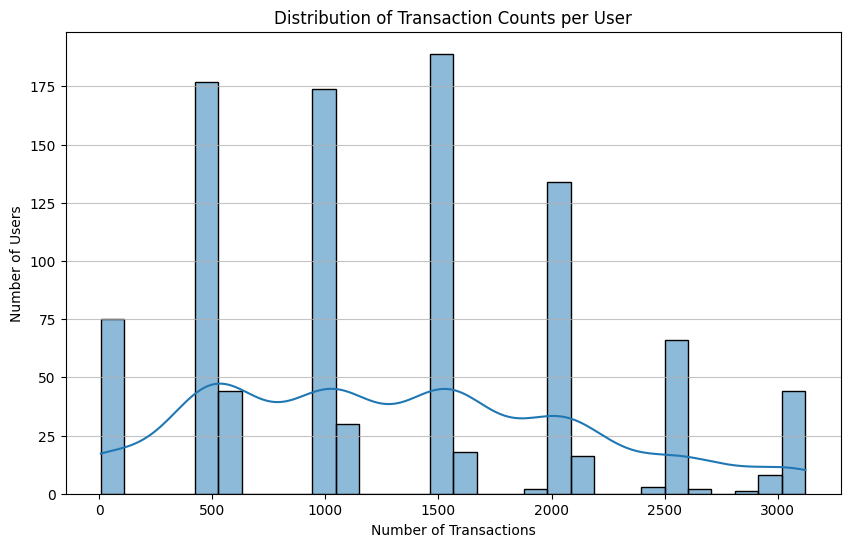

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(transactions_per_user['transaction_count'], bins=30, kde=True)
plt.title('Distribution of Transaction Counts per User')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Average Transaction Rate vs. Fraud Transaction Rate

We will calculate the following averages to compare transaction behavior and fraud:

1.  **Average Total Transactions per User**: The mean number of transactions made by each unique user.
2.  **Average Fraudulent Transactions per User**: The mean number of fraudulent transactions associated with each unique user.
3.  **Overall Fraud Rate**: The total number of fraudulent transactions divided by the total number of all transactions in the dataset.

In [ ]:
# 1. Average total transactions per user
avg_total_transactions_per_user = user_transaction_analysis['transaction_count'].mean()
print(f"Average total transactions per user: {avg_total_transactions_per_user:.2f}")

# 2. Average fraudulent transactions per user
avg_fraudulent_transactions_per_user = user_transaction_analysis['fraudulent_transaction_count'].mean()
print(f"Average fraudulent transactions per user: {avg_fraudulent_transactions_per_user:.2f}")

# 3. Overall fraud rate
total_transactions = user_transaction_analysis['transaction_count'].sum()
total_fraudulent_transactions = user_transaction_analysis['fraudulent_transaction_count'].sum()
overall_fraud_rate = (total_fraudulent_transactions / total_transactions) * 100
print(f"Overall fraud rate (total fraudulent / total transactions): {overall_fraud_rate:.4f}%")

Average total transactions per user: 1319.10
Average fraudulent transactions per user: 7.64
Overall fraud rate (total fraudulent / total transactions): 0.5789%


These metrics provide a high-level overview of transaction activity and fraud prevalence per user and across the entire dataset. Comparing these averages helps in understanding the general scale of fraud relative to legitimate transactions.

#### Comparing Fraudulent Transactions for Low vs. High Fraud Rate Users

To understand the difference in fraudulent transaction counts between users with low and high fraud rates, we will categorize users based on a defined threshold for `fraud_rate`. For this analysis, we'll consider users with a fraud rate below the overall median fraud rate (among users with at least one fraudulent transaction) as 'low fraud rate' users, and those above as 'high fraud rate' users. Then, we will compare their `fraudulent_transaction_count`.

In [ ]:
# Filter users who have at least one fraudulent transaction for meaningful comparison
fraudulent_users_analysis = user_transaction_analysis[user_transaction_analysis['fraudulent_transaction_count'] > 0].copy()

# Define a threshold for 'low' and 'high' fraud rate. Using the median of fraudulent users as a split point.
median_fraud_rate = fraudulent_users_analysis['fraud_rate'].median()
print(f"Median fraud rate among users with fraudulent transactions: {median_fraud_rate:.2f}%")

# Categorize users
fraudulent_users_analysis['fraud_rate_category'] = fraudulent_users_analysis['fraud_rate'].apply(
    lambda x: 'High Fraud Rate' if x >= median_fraud_rate else 'Low Fraud Rate'
)

print("\nDescriptive statistics of fraudulent transaction counts by fraud rate category:")
display(fraudulent_users_analysis.groupby('fraud_rate_category')['fraudulent_transaction_count'].describe())

Median fraud rate among users with fraudulent transactions: 0.80%

Descriptive statistics of fraudulent transaction counts by fraud rate category:


,count,mean,std,min,25%,50%,75%,max
fraud_rate_category,,,,,,,,
High Fraud Rate,382.0,10.568063,2.581852,4.0,9.0,10.0,12.0,19.0
Low Fraud Rate,380.0,9.128947,3.140795,2.0,7.0,9.0,11.0,16.0


#### Visualization: Fraudulent Transaction Counts by Fraud Rate Category

/tmp/ipykernel_659/2934492090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fraud_rate_category', y='fraudulent_transaction_count', data=fraudulent_users_analysis, palette='pastel')


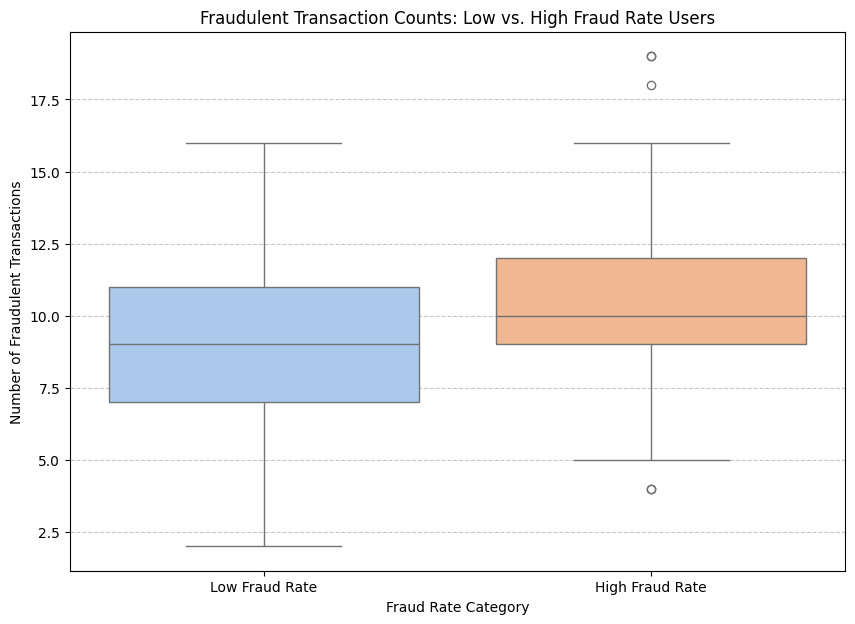

In [ ]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='fraud_rate_category', y='fraudulent_transaction_count', data=fraudulent_users_analysis, palette='pastel')
plt.title('Fraudulent Transaction Counts: Low vs. High Fraud Rate Users')
plt.xlabel('Fraud Rate Category')
plt.ylabel('Number of Fraudulent Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The box plot visually compares the distribution of fraudulent transaction counts for users in the 'low fraud rate' and 'high fraud rate' categories. This helps us understand if users with a higher *proportion* of fraudulent transactions also tend to have a higher *absolute number* of fraudulent transactions, or if these are distinct groups.

This histogram shows how many transactions each user typically makes. A high peak at lower transaction counts indicates that most users have only a few transactions, while a long tail suggests some users are very active.

#### Comparing Total Transactions vs. Fraudulent Transactions per User

In [ ]:
# Count fraudulent transactions per user (cc_num)
fraudulent_transactions_per_user = df_user_transactions[df_user_transactions['is_fraud'] == 1]['cc_num'].value_counts().reset_index()
fraudulent_transactions_per_user.columns = ['cc_num', 'fraudulent_transaction_count']

# Merge with total transactions per user
user_transaction_analysis = pd.merge(
    transactions_per_user,
    fraudulent_transactions_per_user,
    on='cc_num',
    how='left'
)

# Fill NaN values (users with no fraudulent transactions) with 0
user_transaction_analysis['fraudulent_transaction_count'] = user_transaction_analysis['fraudulent_transaction_count'].fillna(0).astype(int)

# Calculate the fraud rate per user
user_transaction_analysis['fraud_rate'] = (user_transaction_analysis['fraudulent_transaction_count'] / user_transaction_analysis['transaction_count']) * 100

print("Top 10 users by fraudulent transaction count:")
display(user_transaction_analysis.sort_values(by='fraudulent_transaction_count', ascending=False).head(10))

print("\nTop 10 users by fraud rate (among those with at least one fraudulent transaction):")
display(user_transaction_analysis[user_transaction_analysis['fraudulent_transaction_count'] > 0].sort_values(by='fraud_rate', ascending=False).head(10))

Top 10 users by fraudulent transaction count:


,cc_num,transaction_count,fraudulent_transaction_count,fraud_rate
684,3520550088202337,989,19,1.921132
908,4593569795412,19,19,100.000000
482,4260128500325,1466,18,1.227831
397,4629451965224809,1531,16,1.045069
792,4874006077381178,516,16,3.100775
238,4400011257587661852,2030,16,0.788177
690,2227671554547514,545,16,2.935780
362,3575540972310993,1542,16,1.037613
94,3556613125071656,2556,16,0.625978
175,30074693890476,2057,16,0.777832



Top 10 users by fraud rate (among those with at least one fraudulent transaction):


,cc_num,transaction_count,fraudulent_transaction_count,fraud_rate
982,4975457191020,7,7,100.0
981,501894933032,7,7,100.0
980,6011732631674654,7,7,100.0
979,4714017207228610634,7,7,100.0
978,4734310647841293,7,7,100.0
961,38534201672254,9,9,100.0
960,3590946339258737,9,9,100.0
959,6500249000784905,9,9,100.0
958,4318414072191879,9,9,100.0
957,6011099828110011,9,9,100.0


#### Visualization: Total Transactions vs. Fraudulent Transactions per User

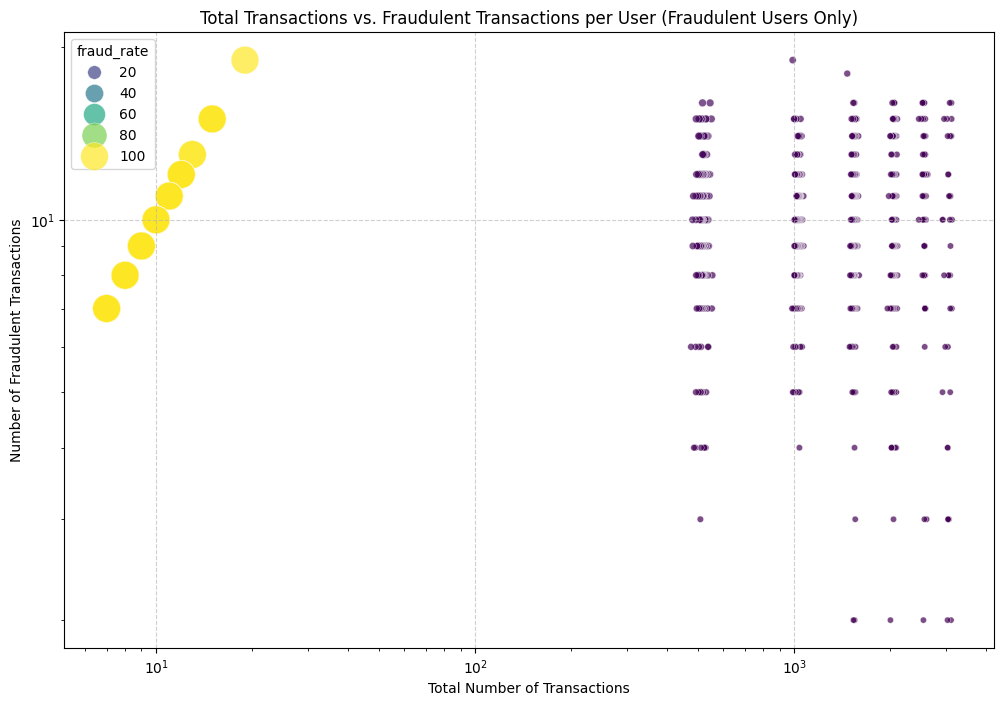

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='transaction_count',
    y='fraudulent_transaction_count',
    hue='fraud_rate',
    size='fraud_rate',
    sizes=(20, 400),
    data=user_transaction_analysis[user_transaction_analysis['fraudulent_transaction_count'] > 0],
    palette='viridis',
    alpha=0.7
)
plt.title('Total Transactions vs. Fraudulent Transactions per User (Fraudulent Users Only)')
plt.xlabel('Total Number of Transactions')
plt.ylabel('Number of Fraudulent Transactions')
plt.xscale('log') # Use log scale for better visualization if transaction counts vary widely
plt.yscale('log') # Use log scale for better visualization if fraudulent counts vary widely
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This scatter plot helps visualize the relationship between the total number of transactions and the number of fraudulent transactions for each user. Users with a higher fraud rate are highlighted, indicating a potential area for further investigation.

## Methodology Summary

This notebook performs an initial exploratory data analysis and basic preprocessing steps on a fraud detection dataset. The methodology can be broken down into the following key stages:

1.  **Data Loading and Initial Inspection**:
    *   Fraud detection training (`fraudTrain.csv`) and test (`fraudTest.csv`) datasets are loaded from a specified Google Drive path.
    *   A custom `load_data` function is used to read CSV files and drop the unnamed index column.
    *   Initial inspection of the data's head and information (`df.info()`) is performed to understand its structure, data types, and non-null counts.

2.  **Feature Engineering and Preprocessing**:
    *   Irrelevant columns such as `cc_num`, `first`, `last`, and `trans_num` are dropped from the DataFrame.
    *   The `trans_date_trans_time` column is converted to datetime objects.
    *   New time-based features (`trans_hour`, `trans_day`, `trans_month`) are extracted from `trans_date_trans_time`.
    *   The `amt` (transaction amount) column is log-transformed (`amt_log = log(amt + 1)`) to handle its skewed distribution and is added as a new feature.

3.  **Exploratory Data Analysis (EDA)**:
    *   **Correlation Matrix**: A heatmap of the correlation matrix for numeric features is generated to understand relationships between variables.
    *   **Outlier Detection**: The IQR method is applied to numeric columns to identify and quantify outliers, noting their presence in columns like `amt`, `city_pop`, `lat`, and `long`.
    *   **Distribution Analysis by Fraud Status**: Box plots are used to visualize the distribution of numeric features (e.g., `amt`, `zip`, `lat`, `long`, `city_pop`, `unix_time`, `merch_lat`, `merch_long`) stratified by the `is_fraud` status.
    *   **Log-Transformed Amount Analysis**: Histograms and box plots are used to specifically analyze the distribution of `amt_log` overall and by fraud status, highlighting differences between fraudulent and non-fraudulent transactions.
    *   **Time-Based Feature Analysis**: Histograms compare the distributions of `trans_hour`, `trans_day`, and `trans_month` for fraudulent vs. non-fraudulent transactions.
    *   **Categorical Feature Analysis**: The number of fraud incidents are analyzed for key categorical features such as `city`, `merchant`, `category`, and `job`, with the top-ranking entries displayed and the top 10 cities by fraud count visualized using a horizontal bar plot.

4.  **Data Persistence**:
    *   A `process_and_select_columns` function is defined to apply the necessary transformations (time feature extraction, log transformation of `amt`) and select a consistent set of columns (`trans_hour`, `category`, `amt_log`, `is_fraud`).
    *   The processed training and test DataFrames are saved to new CSV files (`processed_fraudTrain.csv` and `processed_fraudTest.csv`) in the same Google Drive directory.

5.  **Handling Imbalanced Data**:
    *   The `imblearn` library is installed to address class imbalance.
    *   **Random Undersampling**: Applied using `RandomUnderSampler` to reduce the number of majority class samples, balancing the dataset.
